**Ejemplo simple de planeación de la distribución**

    alejandro.garces@utp.edu.co

In [2]:
# Instalar las librerias
using Pkg
Pkg.add("LinearAlgebra")
Pkg.add("Plots")
Pkg.add("DataFrames")
Pkg.add("JuMP")
Pkg.add("HiGHS")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.

In [3]:
using LinearAlgebra
using DataFrames
using JuMP
using HiGHS
using Plots
theme(:dark)

In [4]:
# Datos de los nodos
Nodes = DataFrame()
Nodes.x = [8, 15, 17, 10, 7, 8, 17, 16, 10, 20, 21, 12, 2, 1, 10, 11, 13, 4, 13, 4, 10, 10, 15, 4]
Nodes.y = [-4, -3, -6, -10, -11, -16, -15, -18, -7, -10, -13, -5, -13, -7, -13, -15, -7, -4, -14, -16, -2, -17, -10, -10]
Nodes.On   = zeros(24)
Nodes.Dem = [2.54,0.50,1.66,0.29,0.18,0.75,2.87,0.46,0.80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
Nodes.Sub = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1]
Nodes.Cost = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,5,5,5]
println(Nodes)

24×6 DataFrame
 Row │ x      y      On       Dem      Sub    Cost  
     │ Int64  Int64  Float64  Float64  Int64  Int64 
─────┼──────────────────────────────────────────────
   1 │     8     -4      0.0     2.54      0      0
   2 │    15     -3      0.0     0.5       0      0
   3 │    17     -6      0.0     1.66      0      0
   4 │    10    -10      0.0     0.29      0      0
   5 │     7    -11      0.0     0.18      0      0
   6 │     8    -16      0.0     0.75      0      0
   7 │    17    -15      0.0     2.87      0      0
   8 │    16    -18      0.0     0.46      0      0
   9 │    10     -7      0.0     0.8       0      0
  10 │    20    -10      0.0     0.0       0      0
  11 │    21    -13      0.0     0.0       0      0
  12 │    12     -5      0.0     0.0       0      0
  13 │     2    -13      0.0     0.0       0      0
  14 │     1     -7      0.0     0.0       0      0
  15 │    10    -13      0.0     0.0       0      0
  16 │    11    -15      0.0     0.0       0  

In [5]:
# Datos de los tramos de línea
Lines = DataFrame()
Lines.Bus1 = [0,0,0,0,0,20,1,1,8,2,2,2,3,3,3,4,4,5,5,5,6,6,6,6,6,7,21,17,13,23,12,12,14,14,16,18,9,22] .+ 1
Lines.Bus2 = [20,8,11,17,4,1,2,11,3,16,9,22,14,16,6,5,23,21,19,15,7,9,22,10,18,21,15,13,23,12,19,14,15,18,9,10,22,10] .+ 1
Lines.On =   zeros(38)
Lines.Smax = 4*ones(38)
Lines.Cost = 0.1*ones(38)
println(Lines)

38×5 DataFrame
 Row │ Bus1   Bus2   On       Smax     Cost    
     │ Int64  Int64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────
   1 │     1     21      0.0      4.0      0.1
   2 │     1      9      0.0      4.0      0.1
   3 │     1     12      0.0      4.0      0.1
   4 │     1     18      0.0      4.0      0.1
   5 │     1      5      0.0      4.0      0.1
   6 │    21      2      0.0      4.0      0.1
   7 │     2      3      0.0      4.0      0.1
   8 │     2     12      0.0      4.0      0.1
   9 │     9      4      0.0      4.0      0.1
  10 │     3     17      0.0      4.0      0.1
  11 │     3     10      0.0      4.0      0.1
  12 │     3     23      0.0      4.0      0.1
  13 │     4     15      0.0      4.0      0.1
  14 │     4     17      0.0      4.0      0.1
  15 │     4      7      0.0      4.0      0.1
  16 │     5      6      0.0      4.0      0.1
  17 │     5     24      0.0      4.0      0.1
  18 │     6     22      0.0      4.0     

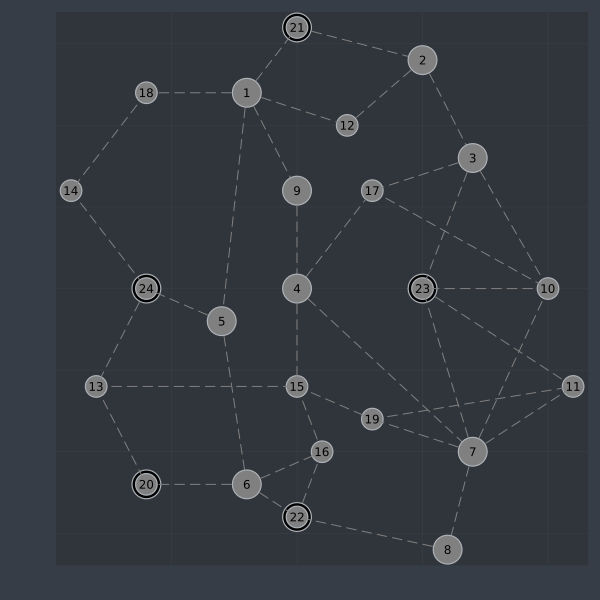

In [6]:
# Grafico
function GraficarRed(Nodes,Lines)
NumN = length(Nodes.x)
NumL = length(Lines.Bus1)
NumS = sum(Nodes.Sub)
plt = scatter(Nodes.x[NumN-NumS:NumN],Nodes.y[NumN-NumS:NumN],legend=false,markersize = 16,color=:black, size=(600,600), axis=false)
plt = scatter!(Nodes.x,Nodes.y,legend=false,markersize = 12,color=:gray)
for k = 1:NumL
    n1 = Lines.Bus1[k]
    n2 = Lines.Bus2[k]
    if Lines.On[k] != 0
       plt = plot!(Nodes.x[[n1,n2]],Nodes.y[[n1,n2]], linewidth=2, linecolor = :orange)
    else
       plt = plot!(Nodes.x[[n1,n2]],Nodes.y[[n1,n2]], linestyle = :dash, linecolor=:gray)
    end
end
for k = 1:NumN
    if Nodes.Dem[k] > 0 # nodos de carga
       plt = scatter!([Nodes.x[k]],[Nodes.y[k]], legend=false, markersize = 16, color=:gray)
    end
    if Nodes.On[k] != 0
       plt = scatter!([Nodes.x[k]],[Nodes.y[k]], legend=false, markersize = 12, color=:orange)
    end
    plt = annotate!(Nodes.x[k],Nodes.y[k],(k,:black,8,:center))
end
return plt
end
GraficarRed(Nodes,Lines)

In [7]:
  # Matriz de incidencia
  function MatrizIncidencia(Lines,Nodes)
    NumN = length(Nodes.x)
    NumL = length(Lines.Bus1)
    A = zeros(NumN,NumL)
    for k = 1:NumL
        n1 = Lines.Bus1[k]
        n2 = Lines.Bus2[k]
        A[n1,k] = 1
        A[n2,k] = -1
    end
    return A
  end
  A=MatrizIncidencia(Lines,Nodes)

24×38 Matrix{Float64}:
  1.0   1.0  1.0   1.0   1.0   0.0   0.0  …   0.0   0.0   0.0  0.0   0.0  0.0
  0.0   0.0  0.0   0.0   0.0  -1.0   1.0      0.0   0.0   0.0  0.0   0.0  0.0
  0.0   0.0  0.0   0.0   0.0   0.0  -1.0      0.0   0.0   0.0  0.0   0.0  0.0
  0.0   0.0  0.0   0.0   0.0   0.0   0.0      0.0   0.0   0.0  0.0   0.0  0.0
  0.0   0.0  0.0   0.0  -1.0   0.0   0.0      0.0   0.0   0.0  0.0   0.0  0.0
  0.0   0.0  0.0   0.0   0.0   0.0   0.0  …   0.0   0.0   0.0  0.0   0.0  0.0
  0.0   0.0  0.0   0.0   0.0   0.0   0.0      0.0   0.0   0.0  0.0   0.0  0.0
  0.0   0.0  0.0   0.0   0.0   0.0   0.0      0.0   0.0   0.0  0.0   0.0  0.0
  0.0  -1.0  0.0   0.0   0.0   0.0   0.0      0.0   0.0   0.0  0.0   0.0  0.0
  0.0   0.0  0.0   0.0   0.0   0.0   0.0      0.0   0.0  -1.0  0.0   1.0  0.0
  ⋮                            ⋮          ⋱                    ⋮          
  0.0   0.0  0.0   0.0   0.0   0.0   0.0  …  -1.0   0.0   0.0  0.0   0.0  0.0
  0.0   0.0  0.0   0.0   0.0   0.0   0.0    

In [8]:
# Modelo de transportes
NumS = sum(Nodes.Sub) # Numero de subestaciones (las NumS últimas)
NumN = length(Nodes.x)
NumL = length(Lines.Bus1)
Pt = sum(Nodes.Dem)
PlanDist = Model(HiGHS.Optimizer)
@variable(PlanDist,g[1:NumN]>=0)
@variable(PlanDist,p[1:NumL])
@variable(PlanDist,zN[1:NumN],Bin)
@variable(PlanDist,zL[1:NumL],Bin)
@objective(PlanDist,Min,sum(Nodes.Cost.*zN)+sum(Lines.Cost.*zL))
@constraint(PlanDist,g .<= Nodes.Sub.*zN*Pt)
@constraint(PlanDist,p .<=  Lines.Smax.*zL)
@constraint(PlanDist,p .>= -Lines.Smax.*zL)
@constraint(PlanDist,g-Nodes.Dem == A*p)
@constraint(PlanDist,sum(zL) == sum(zN)-1)
@constraint(PlanDist,sum(zN[(NumN-NumS):NumN]) == 1) # Solo una sola subestacion
@constraint(PlanDist, zN .<= abs.(A)*zL) # si un nodo se activa, al menos una linea adjacente se activa
optimize!(PlanDist)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
MIP has 150 rows; 124 cols; 447 nonzeros; 62 integer variables (62 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+01]
  Cost    [1e-01, 5e+00]
  Bound   [1e+00, 1e+00]
  RHS     [2e-01, 3e+00]
Presolving model
124 rows, 98 cols, 395 nonzeros 0s
108 rows, 82 cols, 411 nonzeros 0s
Presolve reductions: rows 108(-42); columns 82(-42); nonzeros 411(-36) 
Objective function is integral with scale 10

Solving MIP model with:
   108 rows
   82 cols (61 binary, 0 integer, 0 implied int., 21 continuous, 0 domain fixed)
   411 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u =>

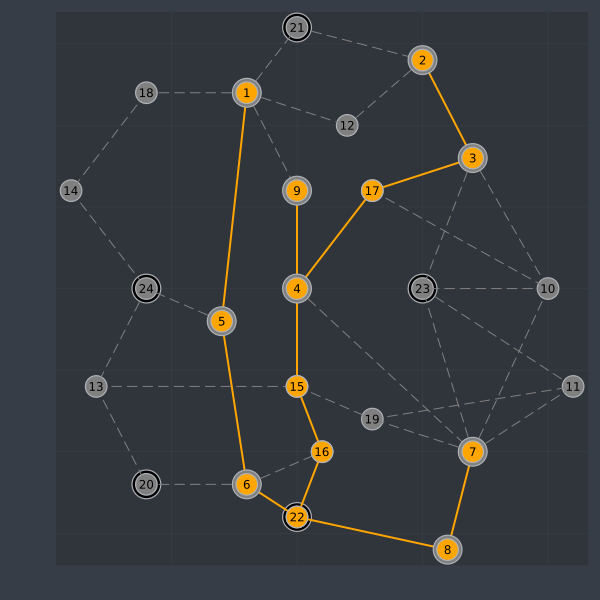

In [9]:
ResN = Nodes
ResL = Lines
ResN.On = value.(zN)
ResL.On = value.(zL)
GraficarRed(ResN,ResL)